In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

df_scaled = pd.read_csv('../data/heart_scaled.csv')
X = df_scaled[['thal', 'ca', 'slope', 'thalach', 'exang', 'sex', 'oldpeak', 'cp']]
y = df_scaled['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Accuracy: 0.852
Precision: 0.871
Recall: 0.844
F1 Score: 0.857
Test set score: 0.852


Cross-validation scores: [0.735 0.857 0.875 0.854 0.833]
Mean accuracy: 0.831
best parameters: {'C': 1, 'l1_ratio': 0, 'penalty': 'l2', 'solver': 'saga'}
best score(grid search): 0.831


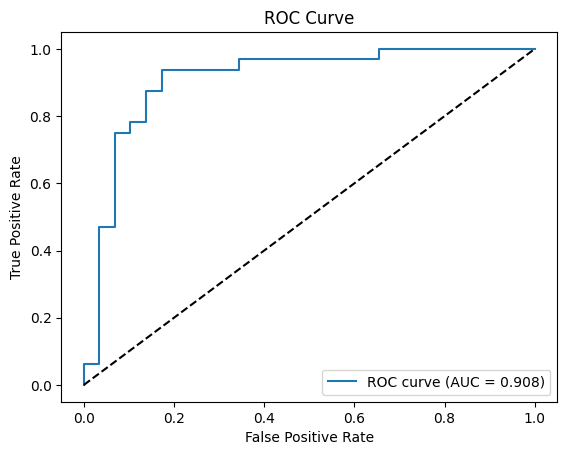

Confusion matrix:
 [[25  4]
 [ 5 27]]


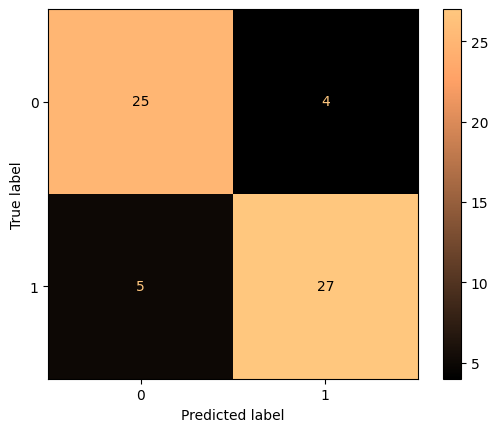

In [ ]:
# Logistic Regression
model=LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag'], 
    'l1_ratio': [0, 0.5, 0.9, 1] ,  
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
scores = cross_val_score(best_model, X_train, y_train, cv=5)
y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
score=best_model.score(X_test,y_test)

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)


print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Test set score:", round(score, 3))
print('\n')
print("Cross-validation scores:", np.round(scores,3))
print("Mean accuracy:", round(scores.mean(), 3))
print("best parameters:", grid_search.best_params_)
print("best score(grid search):", round(grid_search.best_score_, 3))


plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='copper')

Accuracy: 0.852
Precision: 0.871
Recall: 0.844
F1 Score: 0.857
Test set score: 0.852


Cross-validation scores: [0.796 0.776 0.812 0.792 0.854]
Mean accuracy: 0.806
best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
best score(grid search): 0.803


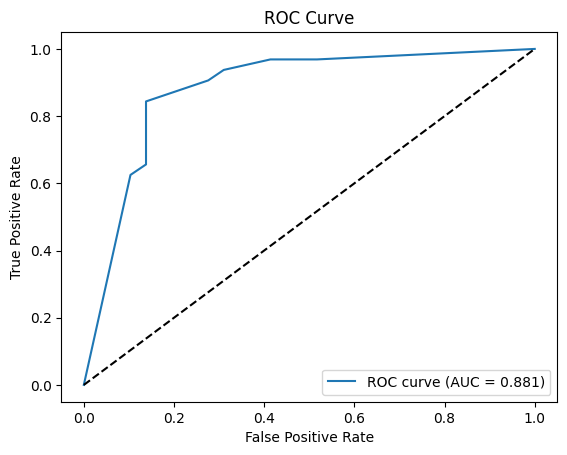

Confusion matrix:
 [[25  4]
 [ 5 27]]


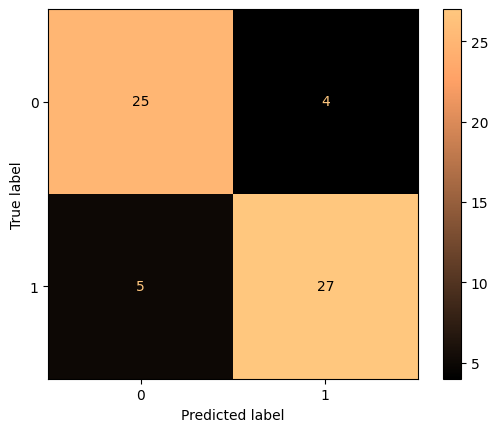

In [ ]:
# Decision Tree
model = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"], 
    "max_depth": [None, 5, 10, 20],   
    "min_samples_split": [2, 5, 10],  
    "min_samples_leaf": [1, 2, 4]     
}
grid_search = GridSearchCV(model, param_grid, cv=15, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
scores = cross_val_score(best_model, X_train, y_train, cv=5)
y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
score=best_model.score(X_test,y_test)

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)


print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Test set score:", round(score, 3))
print('\n')
print("Cross-validation scores:", np.round(scores,3))
print("Mean accuracy:", round(scores.mean(), 3))
print("best parameters:", grid_search.best_params_)
print("best score(grid search):", round(grid_search.best_score_, 3))


plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='copper')

Accuracy: 0.885
Precision: 0.879
Recall: 0.906
F1 Score: 0.892
Test set score: 0.885


Cross-validation scores: [0.816 0.857 0.875 0.896 0.833]
Mean accuracy: 0.856
best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
best score(grid search): 0.856


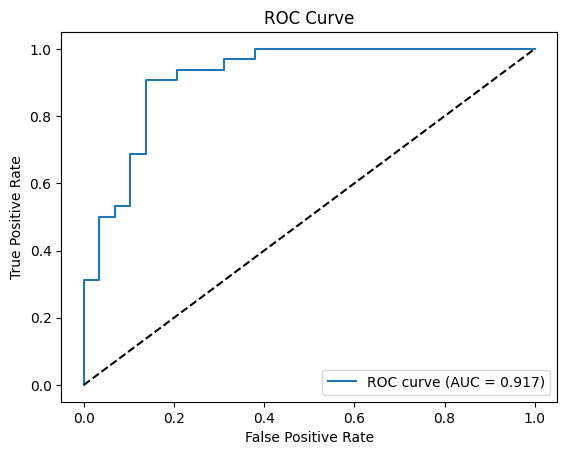

Confusion matrix:
 [[25  4]
 [ 3 29]]


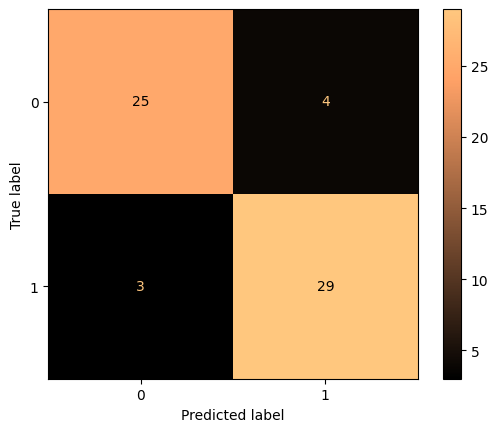

In [ ]:
# Random Forest
model=RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],  
    "max_depth": [None, 10, 20, 30], 
    "min_samples_split": [2, 5, 10],  
    "min_samples_leaf": [1, 2, 4],   
    "max_features": ["auto", "sqrt", "log2", None] 
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
scores = cross_val_score(best_model, X_train, y_train, cv=5)
y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
score=best_model.score(X_test,y_test)

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)


print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Test set score:", round(score, 3))
print('\n')
print("Cross-validation scores:", np.round(scores,3))
print("Mean accuracy:", round(scores.mean(), 3))
print("best parameters:", grid_search.best_params_)
print("best score(grid search):", round(grid_search.best_score_, 3))


plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='copper')

Accuracy: 0.885
Precision: 0.857
Recall: 0.938
F1 Score: 0.896
Test set score: 0.885


Cross-validation scores: [0.755 0.837 0.896 0.833 0.833]
Mean accuracy: 0.831
best parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
best score(grid search): 0.831


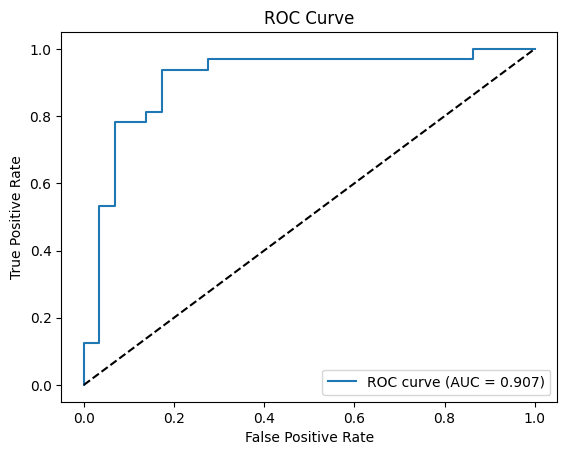

Confusion matrix:
 [[24  5]
 [ 2 30]]


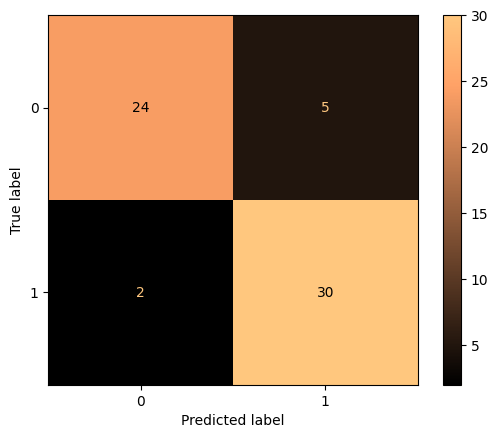

In [ ]:
# SVM model

model = SVC(random_state=42, max_iter=10000000, probability=True)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "gamma": ["scale", "auto", 0.01, 0.1, 1, 10],
    
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
scores = cross_val_score(best_model, X_train, y_train, cv=5)
y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
score=best_model.score(X_test,y_test)

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)


print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("Test set score:", round(score, 3))
print('\n')
print("Cross-validation scores:", np.round(scores,3))
print("Mean accuracy:", round(scores.mean(), 3))
print("best parameters:", grid_search.best_params_)
print("best score(grid search):", round(grid_search.best_score_, 3))



plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='copper')

In [3]:
#saving the best model for the app
import joblib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

df_processed=pd.read_csv('../data/heart_processed.csv')
X = df_processed[['thal', 'ca', 'slope', 'thalach', 'exang', 'sex', 'oldpeak', 'cp','age']]
y = df_processed['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  
    ('svm', SVC(C= 1, gamma= 0.1, kernel= 'rbf',probability=True)) 
])
pipeline.fit(X_train, y_train)

joblib.dump((pipeline,X.columns.tolist()), "heart_model.pkl")


['heart_model.pkl']